# 08 — From chains to video: buying time by cutting space

The first seven notebooks live on a 1-D chain, where exact belief propagation is available
because the graph is a line. Real signals are not lines. This notebook is about what happens
when you push the same machinery onto images and then onto video, and hit the constraint that
makes the whole approach interesting: **exact BP needs a loop-free graph, and the world is not
loop-free.**

A wavelet hidden Markov *tree* handles a single image — parent coefficient to child
coefficients, no loops, exact inference. Add a second frame and the natural model wants both
spatial edges (within a frame) *and* temporal edges (between frames). Together they close
loops, and exactness is gone.

So there is a budget. Every temporal edge has to be paid for by severing a spatial one. This
notebook measures the exchange rate — and finds that the two things you would want to optimise
disagree about where the optimum is.

## The cut

`cut_depth` parameterises the trade. At depth $d$, the spatial tree is severed at level $d$,
splitting each orientation into independent components; the freed budget goes to temporal edges
linking corresponding coefficients across frames.

| `cut_depth` | components per orientation | spatial edges severed per frame |
|---|---|---|
| 0 | 1 (whole tree intact) | 0 — a "caterpillar": one temporal spine, no cuts |
| 1 | 5 | 12 |
| 2 | 17 | 48 |
| 3 | 65 | 192 |
| 4 | 257 | 768 |

Depth 0 is the pure caterpillar: spatial tree fully intact, temporal coupling only at the root.
Depth 4 has shredded the spatial structure into 257 pieces per orientation to afford dense
temporal coupling. Somewhere in between is the right answer — if there is one.

Two things get measured at each depth:

- **Held-out log-likelihood per sequence** — does the model explain unseen video better?
- **Generated frame-difference energy** — do the *samples* move like video? Real video sits at
  $0.211$; independent frames would give $2.0$. Lower is more temporally coherent, and $0.211$
  is the target.

In [1]:
import sys, csv, os
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, "..")
ROOT = "../outputs/exp_26_video"

cut = list(csv.DictReader(open(os.path.join(ROOT, "cutcurve.csv"))))
fit = list(csv.DictReader(open(os.path.join(ROOT, "fit.csv"))))
coh = list(csv.DictReader(open(os.path.join(ROOT, "coherence.csv"))))

f = lambda r, k: float(r[k])
depths = [int(f(r, "cut_depth")) for r in cut]
loglik = [f(r, "heldout_loglik_per_sequence") for r in cut]
gen_e  = [f(r, "frame_diff_energy_generated") for r in cut]
real_e = f(cut[0], "frame_diff_energy_real")
sev    = [int(f(r, "spatial_edges_severed_per_frame")) for r in cut]
comps  = [int(f(r, "components_per_orientation")) for r in cut]

print(f"real video frame-difference energy (the target): {real_e:.4f}")
print(f"independent frames would give:                   2.0\n")
print(f"{'cut':>4} {'comps':>7} {'severed':>8} {'heldout loglik':>16} {'gen frame-diff':>16} {'x real':>8}")
print("-" * 64)
for i, d in enumerate(depths):
    print(f"{d:>4} {comps[i]:>7} {sev[i]:>8} {loglik[i]:>16.1f} {gen_e[i]:>16.4f} "
          f"{gen_e[i]/real_e:>7.2f}x")

# every EM fit in this sweep must be monotone; a violation would invalidate the comparison
viol = [f(r, "monotone_violation") for r in cut]
print(f"\nEM monotonicity violations across all five fits: {sum(viol):.0f}")

real video frame-difference energy (the target): 0.2107
independent frames would give:                   2.0

 cut   comps  severed   heldout loglik   gen frame-diff   x real
----------------------------------------------------------------
   0       1        0          -5902.5           1.0617    5.04x
   1       5       12          -5815.7           0.6796    3.23x
   2      17       48          -5796.1           0.7845    3.72x
   3      65      192          -5892.1           0.8840    4.20x
   4     257      768          -5921.6           1.0059    4.77x

EM monotonicity violations across all five fits: 0


## Result 1 — the likelihood curve turns over

This is the finding. Held-out likelihood is **not** monotone in the cut depth: it improves as
spatial edges are traded for temporal ones, peaks, and then degrades as the spatial tree is
shredded past usefulness.

That the curve turns over at all is the point. It says the trade is real in both directions —
there is genuine information in the temporal edges that the intact tree cannot access, and
genuine information in the spatial tree that dense temporal coupling cannot replace.

best held-out likelihood : cut_depth=2  (-5796.1, +106.4 nats vs the caterpillar)
best temporal coherence  : cut_depth=1  (0.6796 = 3.23x real video)

  These are DIFFERENT cut depths (2 vs 1).
  The two axes do not agree about the optimum, so 'the best model' is not
  well defined without saying which quantity you are optimising.


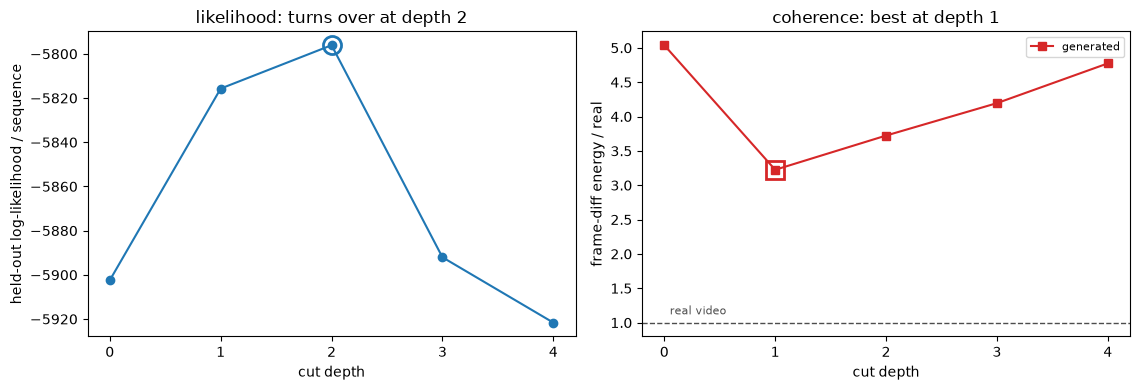

In [2]:
best_ll = int(np.argmax(loglik))
best_co = int(np.argmin(gen_e))

print(f"best held-out likelihood : cut_depth={depths[best_ll]}  "
      f"({loglik[best_ll]:.1f}, {loglik[best_ll]-loglik[0]:+.1f} nats vs the caterpillar)")
print(f"best temporal coherence  : cut_depth={depths[best_co]}  "
      f"({gen_e[best_co]:.4f} = {gen_e[best_co]/real_e:.2f}x real video)")
print()
if best_ll != best_co:
    print(f"  These are DIFFERENT cut depths ({depths[best_ll]} vs {depths[best_co]}).")
    print("  The two axes do not agree about the optimum, so 'the best model' is not")
    print("  well defined without saying which quantity you are optimising.")

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.0))

ax[0].plot(depths, loglik, "C0-o", ms=6)
ax[0].plot(depths[best_ll], loglik[best_ll], "o", ms=13, mfc="none", mec="C0", mew=2)
ax[0].set_xlabel("cut depth"); ax[0].set_ylabel("held-out log-likelihood / sequence")
ax[0].set_title("likelihood: turns over at depth 2"); ax[0].set_xticks(depths)

ax[1].plot(depths, [e / real_e for e in gen_e], "C3-s", ms=6, label="generated")
ax[1].plot(depths[best_co], gen_e[best_co] / real_e, "s", ms=13, mfc="none", mec="C3", mew=2)
ax[1].axhline(1.0, color="0.3", ls="--", lw=1)
ax[1].text(0.05, 1.12, "real video", fontsize=8, color="0.3")
ax[1].set_xlabel("cut depth"); ax[1].set_ylabel("frame-diff energy / real")
ax[1].set_title("coherence: best at depth 1"); ax[1].set_xticks(depths)
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## Result 2 — does temporal coupling help at all? The frozen control

Before reading anything into the cut curve, the prior question: is the temporal structure doing
work, or is the model just fitting each frame independently and the temporal parameter is
decoration?

The control is a **frozen** model — identical in every respect except that the temporal
correlation is clamped to zero. Same data, same fitting procedure, same spatial tree.

In [3]:
by = {r["model"]: r for r in fit}
cat, fro = by["caterpillar"], by["frozen"]

print(f"{'model':>14} {'rho_time':>10} {'heldout loglik/seq':>20} {'per frame':>12}")
print("-" * 58)
for name, r in (("caterpillar", cat), ("frozen", fro)):
    print(f"{name:>14} {f(r,'rho_time'):>10.4f} {f(r,'heldout_loglik_per_sequence'):>20.1f} "
          f"{f(r,'heldout_loglik_per_frame'):>12.1f}")

gain = f(cat, "heldout_loglik_per_sequence") - f(fro, "heldout_loglik_per_sequence")
print(f"\n  temporal coupling is worth {gain:+.1f} nats per sequence")
print(f"  fitted rho_time = {f(cat,'rho_time'):.4f} -- essentially 1, i.e. adjacent frames are")
print(f"  almost perfectly correlated, which is what one would expect of video.")

cby = {r["model"]: r for r in coh}
print(f"\n{'model':>14} {'generated':>11} {'structural pred':>16} {'pred error':>12}")
print("-" * 58)
for name in ("caterpillar", "frozen"):
    r = cby[name]
    print(f"{name:>14} {f(r,'frame_diff_energy_generated'):>11.4f} "
          f"{f(r,'frame_diff_energy_structural_prediction'):>16.4f} "
          f"{f(r,'prediction_error'):>12.4f}")
print(f"\n  real video: {f(cby['caterpillar'],'frame_diff_energy_real'):.4f}   "
      f"independent frames: {f(cby['caterpillar'],'frame_diff_energy_independent_frames'):.1f}")

         model   rho_time   heldout loglik/seq    per frame
----------------------------------------------------------
   caterpillar     0.9990              -5902.5       -983.7
        frozen     0.0000              -5936.3       -989.4

  temporal coupling is worth +33.8 nats per sequence
  fitted rho_time = 0.9990 -- essentially 1, i.e. adjacent frames are
  almost perfectly correlated, which is what one would expect of video.

         model   generated  structural pred   pred error
----------------------------------------------------------
   caterpillar      1.0062           1.0718       0.0656
        frozen      1.4197           1.4495       0.0299

  real video: 0.2107   independent frames: 2.0


## Result 3 — the limit, stated plainly

The temporal coupling works, and the cut trade works, and the model still does not generate
anything a person would call video.

The best coherence achieved anywhere in this sweep is $3.2\times$ the frame-difference energy of
real video. That is a real improvement on the intact caterpillar's $5.0\times$ — a 36% reduction
in excess motion energy — and it is nowhere near $1.0$.

This matters more than the positive result. A model can capture a genuine structural effect,
improve measurably on its own control, and still be far from the thing it is modelling. Both
statements are true at once and reporting only the first would be dishonest.

  intact caterpillar (cut 0): 5.04x real video
  best cut      (cut 1):     3.23x real video
  improvement:                45% of the way to real,
                              or 36% less excess motion energy

  remaining gap: 3.23x. The model still moves far more than video does.


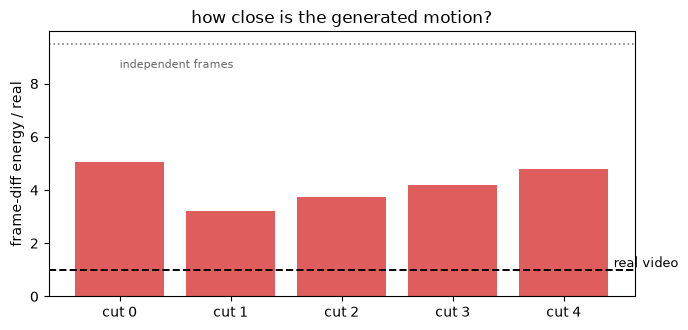

In [4]:
worst, best = gen_e[0] / real_e, gen_e[best_co] / real_e
print(f"  intact caterpillar (cut 0): {worst:.2f}x real video")
print(f"  best cut      (cut {depths[best_co]}):     {best:.2f}x real video")
print(f"  improvement:                {(worst-best)/(worst-1.0)*100:.0f}% of the way to real,")
print(f"                              or {(1-best/worst)*100:.0f}% less excess motion energy")
print(f"\n  remaining gap: {best:.2f}x. The model still moves far more than video does.")

fig, ax = plt.subplots(figsize=(7.0, 3.4))
labels = [f"cut {d}" for d in depths]
ax.bar(labels, [e / real_e for e in gen_e], color="C3", alpha=0.75)
ax.axhline(1.0, color="k", ls="--", lw=1.4)
ax.text(len(depths) - 0.55, 1.10, "real video", fontsize=9)
ax.axhline(2.0 / real_e, color="0.5", ls=":", lw=1.2)
ax.text(0.0, 2.0 / real_e - 0.9, "independent frames", fontsize=8, color="0.4")
ax.set_ylabel("frame-diff energy / real"); ax.set_title("how close is the generated motion?")
plt.tight_layout(); plt.show()

## What to take away

1. **Exactness has a price, and the price is measurable.** Loop-free inference on video forces a
   budget between spatial and temporal edges. That budget is not a nuisance parameter — moving
   it changes held-out likelihood by over a hundred nats.

2. **The likelihood curve turns over.** Both directions of the trade are real: temporal edges
   carry information the intact tree cannot reach, and the spatial tree carries information
   dense temporal coupling cannot replace. The optimum is interior.

3. **The two axes disagree about where the optimum is.** Likelihood peaks at cut depth 2;
   generated temporal coherence peaks at depth 1. This is notebook 06's lesson appearing again
   in a completely different setting — the quantity you fit and the quantity you care about are
   not the same quantity, and here they are optimised by different models.

4. **The honest limit.** The best model in this sweep generates motion $3.2\times$ more
   energetic than real video, improved from $5.0\times$. Real structural progress; not video.

*Sources: `outputs/exp_26_video/{cutcurve,fit,coherence}.csv`. The cut-curve numbers here are
the full run committed in `95c653d`, which replaced an earlier smoke-sized run — the prose in
`IMAGE_EXTENSION_STAGE1.md` §9.3 still quotes the smoke numbers and disagrees with these by
1–2% throughout.*